# Breast Cancer Classification — Logistic Regression

**Master's in Applied Artificial Intelligence (MNA)** · Tecnológico de Monterrey
Course TC5053 — Data Science and Analytics · Week 9: Logistic Regression

**Author:** Ricardo Martín Galván Páez

---

## Overview

This notebook analyzes the `breast_cancer.csv` dataset (*Breast Cancer Wisconsin – Diagnostic*, UCI Machine Learning Repository) and builds **logistic regression** models that classify a tumor as malignant (`M`) or benign (`B`). The **target variable** is `diagnosis`.

| Step | Section | Technique |
|---|---|---|
| 1 | Loading and inspection | `info()`, missing values, duplicates, statistics with skewness and kurtosis |
| 2 | EDA | Target distribution, pairplot, stacked histograms |
| 3 | Correlation and feature selection | Pairs with \|r\| > 0.9, correlation with the target, heatmap |
| 4 | Split and evaluation | 80:20 (`random_state=1`), `evaluate_model` function |
| 5 | Model 1 | Correlated features removed, no scaling (*Correlation_Clean*) |
| 6 | Model 2 | `StandardScaler` + PCA (≥ 90 % of the variance) (*Standard_PCA*) |
| 7 | Model 3 | Yeo-Johnson (*Correlation_Yeo*) and a `StandardScaler`-only control |
| 8 | Coefficients | The 10 most influential predictors |
| 9 | Best-model evaluation | Confusion matrix and ROC curve |
| 10 | Probabilities and threshold | Probability distribution, threshold analysis |

**Running the notebook:** it runs in Google Colab (the CSV is read from Google Drive) or locally (place the CSV at `data/breast_cancer.csv`).

> **Disclaimer:** educational project. The model is not a clinical diagnostic tool.

## Dataset description

The data describes breast tumors from digitized images of a fine-needle aspirate (FNA). Every feature is computed over the **cell nuclei** visible in the image. The goal is to determine whether a tumor is malignant (`M`) or benign (`B`). There are 569 records, 30 numeric variables, `diagnosis` and `id`.

Each of the 10 features comes in three measures:

| Suffix | Meaning |
|---|---|
| `_mean` | Mean of the feature over all nuclei in the image |
| `_se` | Standard error of the feature |
| `_worst` | Mean of the three largest values (the "worst" value) |

| Feature | Description |
|---|---|
| `radius` | Radius: mean distance from the center to points on the contour |
| `texture` | Texture: standard deviation of gray-scale values |
| `perimeter` | Perimeter |
| `area` | Area |
| `smoothness` | Smoothness: local variation in radius lengths |
| `compactness` | Compactness: perimeter² / area − 1 |
| `concavity` | Concavity: severity of the concave portions of the contour |
| `concave points` | Concave points: number of concave portions of the contour |
| `symmetry` | Symmetry |
| `fractal_dimension` | Fractal dimension: "coastline approximation" − 1 (contour complexity) |
| `diagnosis` | Benign (`B`) or malignant (`M`). **Target variable** |

> **Note.** The same data ships with scikit-learn (`sklearn.datasets.load_breast_cancer`), with different column names.

---

## 0. Setup

In [1]:
# Import the required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [2]:
# Data location: Google Drive when running in Colab, ./data/ when running locally
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/Posgrado/1er trimestre/TC5053.10_Ciencia y analítica de datos/Colab/Actividad 9 | Regresión logística"
except ImportError:
    DATA_DIR = "data"  # local run: place breast_cancer.csv in ./data/

Mounted at /content/drive


---

## 1. Data loading and initial inspection

**Goals**
- Load all records into a dataframe (`cancer_df`) and use the `id` column as the index.
- Summarize the data types with `info()`: how many columns are numeric and how many are text?
- Check for missing values and duplicate records.
- Compute descriptive statistics: numeric (with skewness and kurtosis) and categorical.

In [3]:
cancer_df = pd.read_csv(os.path.join(DATA_DIR, 'breast_cancer.csv'))
cancer_df.set_index('id', inplace=True)
cancer_df.info()
print('='*50)
num_cols = cancer_df.select_dtypes(include='number').columns
cat_cols = cancer_df.select_dtypes(exclude='number').columns

print(f'Numeric columns: {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print('='*50)

# Missing values
print(f'Missing values: \n{cancer_df.isnull().sum()}')
print('='*50)

# Duplicate records
print(f'Duplicate records: {cancer_df.duplicated().sum()}')
print('='*50)

# Descriptive statistics
print('Descriptive statistics (numeric):')
describe_df = cancer_df[num_cols].describe().T
describe_df['skewness'] = cancer_df[num_cols].skew()
describe_df['kurtosis'] = cancer_df[num_cols].kurtosis()
display(describe_df)
print('='*50)
print('Descriptive statistics (categorical):')
display(cancer_df[cat_cols].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                 

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,0.942380,0.845522
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,0.650450,0.758319
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,0.990650,0.972214
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,1.645732,3.652303
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.456324,0.855975
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,1.190123,1.650130
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,1.401180,1.998638
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,1.171180,1.066556
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.725609,1.287933
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,1.304489,3.005892


Descriptive statistics (categorical):


,diagnosis
count,569
unique,2
top,B
freq,357


**Result.** The dataframe has 569 records, 30 numeric columns and 1 text column (`diagnosis`). There are no missing values and no duplicate records, so no cleaning is needed. Several size and standard-error variables are strongly skewed (e.g. `area_se` 5.4, `concavity_se` 5.1), which motivates the transformation in Section 7.

---

## 2. Exploratory data analysis

**Goals**
- Compute and plot the percentage distribution of `diagnosis`. Why does it matter in classification?
- Generate a pairplot of the size-related `_mean` variables (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`), colored by `diagnosis`.
- Create stacked histograms of the morphological `_mean` variables, colored by `diagnosis`, to see which ones separate the classes best.

### 2.1 Target distribution

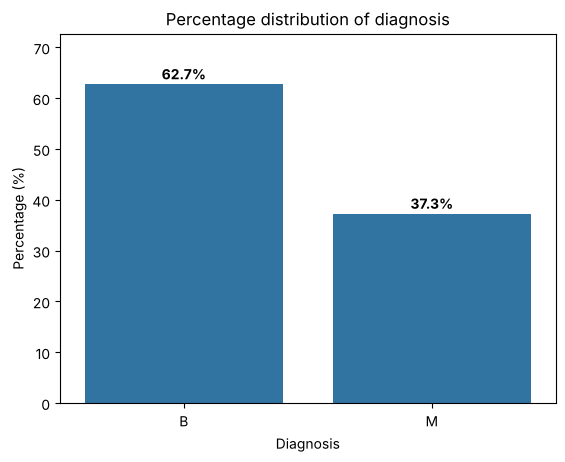

In [4]:
# Target distribution (%)
dist = cancer_df['diagnosis'].value_counts(normalize=True) * 100

ax = sns.barplot(x=dist.index, y=dist.values)
# Add the percentage on top of each bar
for i, v in enumerate(dist.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.title('Percentage distribution of diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Percentage (%)')
plt.ylim(0, max(dist.values) + 10)
plt.show()

**Result.** 62.7 % of the tumors are benign (357) and 37.3 % malignant (212): a moderate imbalance. It matters because a model that always predicted "benign" would reach 62.7 % accuracy while learning nothing and with **0 % recall** on malignant tumors. Accuracy must therefore always be read against that baseline and complemented with recall and precision.

### 2.2 Size variables: pairplot

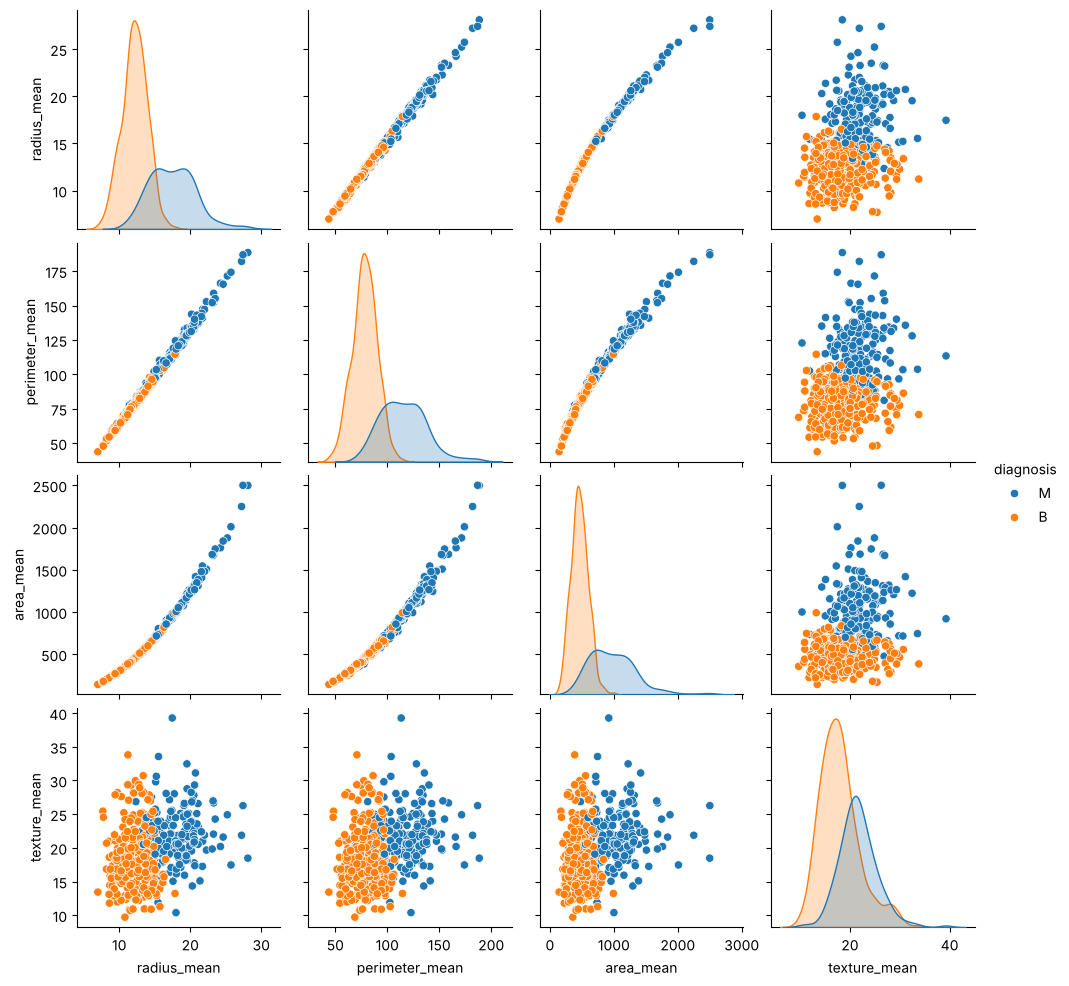

In [5]:
# Pairplot of the physical _mean variables
sns.pairplot(cancer_df[['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean', 'diagnosis']], hue='diagnosis')
plt.show()

**Result.**
- `radius_mean`, `perimeter_mean` and `area_mean` are almost perfectly correlated (r ≈ 0.99): they are geometric functions of the same size (perimeter = 2πr, area = πr²). The relationship of the area with the other two is slightly curved, not strictly linear. Keeping all three adds redundant information.
- Malignant tumors concentrate at larger sizes, although they overlap somewhat with benign ones.
- `texture_mean` also separates the classes, with more overlap than the size variables, and is only weakly correlated with them: it adds complementary information.

### 2.3 Morphological variables: stacked histograms

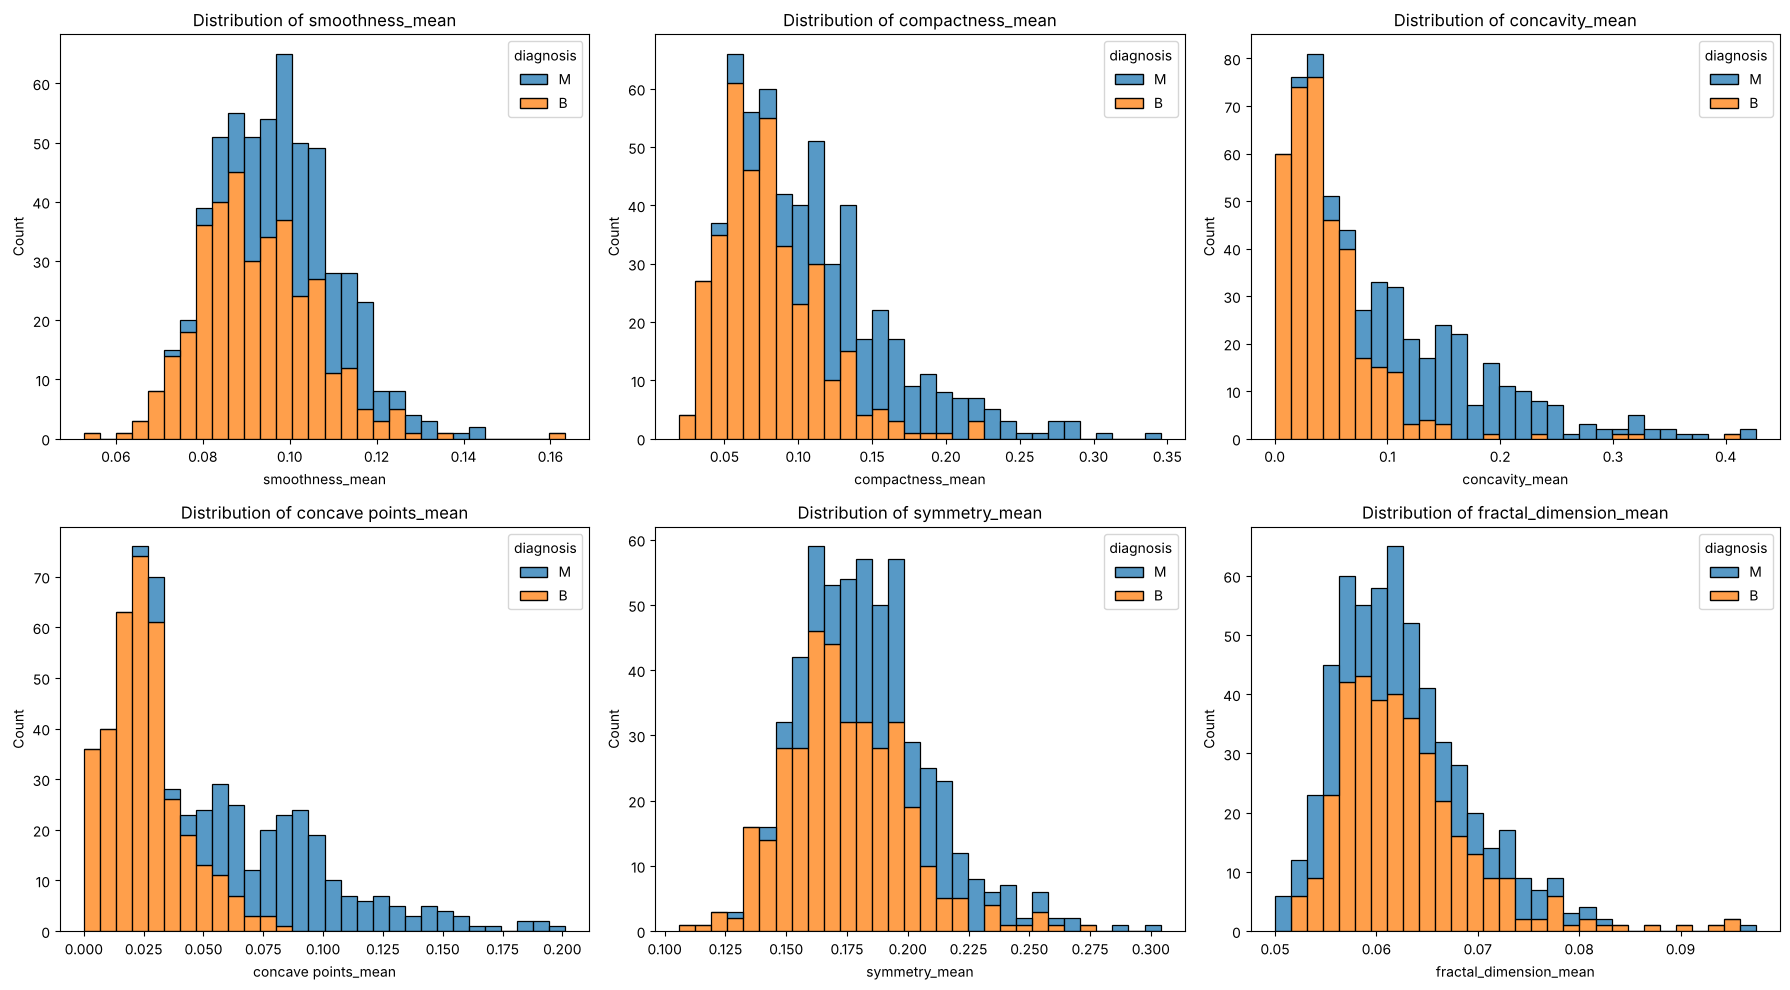

In [6]:
morphological = ['smoothness_mean', 'compactness_mean', 'concavity_mean',
                 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(morphological):
    sns.histplot(data=cancer_df, x=col, hue='diagnosis', multiple='stack',
                 bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Result.** `concave points_mean` and `concavity_mean` discriminate best: at medium and high values there are almost only malignant tumors, while at low values both classes overlap. `concave points_mean` is the cleanest (benign maximum ≈ 0.085 vs. malignant maximum ≈ 0.20); `concavity_mean` has a few benign outliers at high values. `compactness_mean` discriminates moderately; `smoothness_mean`, `symmetry_mean` and `fractal_dimension_mean` overlap heavily and discriminate little on their own.

---

## 3. Correlation and feature selection

**Goals**
- Create a copy of the dataframe (`cancer_copy`) for the correlation analysis.
- Identify the pairs with correlation above 0.9. The high correlation between `_mean` and `_worst` is expected (they measure the same feature), so the `_worst` columns are dropped.
- Repeat the search. Among `radius`, `perimeter` and `area` (and other groups), keep one variable per group and justify the choice.
- Draw the heatmap to see which relevant correlations remain.

In [7]:
cancer_copy = cancer_df.copy()

In [8]:
# Pairs with correlation above 0.9
corr_matrix = cancer_copy.corr(numeric_only=True)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
high_corr_df = pd.DataFrame(high_corr, columns=['Variable 1', 'Variable 2', 'Correlation']).sort_values(by='Correlation', ascending=False)
display(high_corr_df)

,Variable 1,Variable 2,Correlation
0,radius_mean,perimeter_mean,0.997855
18,radius_worst,perimeter_worst,0.993708
1,radius_mean,area_mean,0.987357
6,perimeter_mean,area_mean,0.986507
19,radius_worst,area_worst,0.984015
20,perimeter_worst,area_worst,0.977578
15,radius_se,perimeter_se,0.972794
8,perimeter_mean,perimeter_worst,0.970387
2,radius_mean,radius_worst,0.969539
7,perimeter_mean,radius_worst,0.969476


In [9]:
# Drop the _worst columns
worst_cols = [col for col in cancer_copy.columns if '_worst' in col]
cancer_copy.drop(columns=worst_cols, inplace=True)

# Pairs with correlation above 0.9
corr_matrix = cancer_copy.corr(numeric_only=True)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
high_corr_df = pd.DataFrame(high_corr, columns=['Variable 1', 'Variable 2', 'Correlation']).sort_values(by='Correlation', ascending=False)
display(high_corr_df)

,Variable 1,Variable 2,Correlation
0,radius_mean,perimeter_mean,0.997855
1,radius_mean,area_mean,0.987357
2,perimeter_mean,area_mean,0.986507
4,radius_se,perimeter_se,0.972794
5,radius_se,area_se,0.951830
6,perimeter_se,area_se,0.937655
3,concavity_mean,concave points_mean,0.921391


**Selection criterion.** Within each group of highly correlated variables, the one with the highest individual correlation with the target is kept:

- **Size `_mean` group:** `perimeter_mean` (0.743) over `radius_mean` (0.730) and `area_mean` (0.709).
- **Size `_se` group:** `radius_se` (0.567) over `perimeter_se` (0.556) and `area_se` (0.548).
- **Concavity:** `concave points_mean` (0.777) over `concavity_mean` (0.696).

In [10]:
# Individual correlation with the target
diagnosis_num = cancer_df['diagnosis'].map({'M': 1, 'B': 0})
print(cancer_df[['radius_mean', 'perimeter_mean', 'area_mean']].corrwith(diagnosis_num))
print(cancer_df[['radius_se', 'perimeter_se', 'area_se']].corrwith(diagnosis_num))
print(cancer_df[['concavity_mean', 'concave points_mean']].corrwith(diagnosis_num))

radius_mean       0.730029
perimeter_mean    0.742636
area_mean         0.708984
dtype: float64
radius_se       0.567134
perimeter_se    0.556141
area_se         0.548236
dtype: float64
concavity_mean         0.696360
concave points_mean    0.776614
dtype: float64


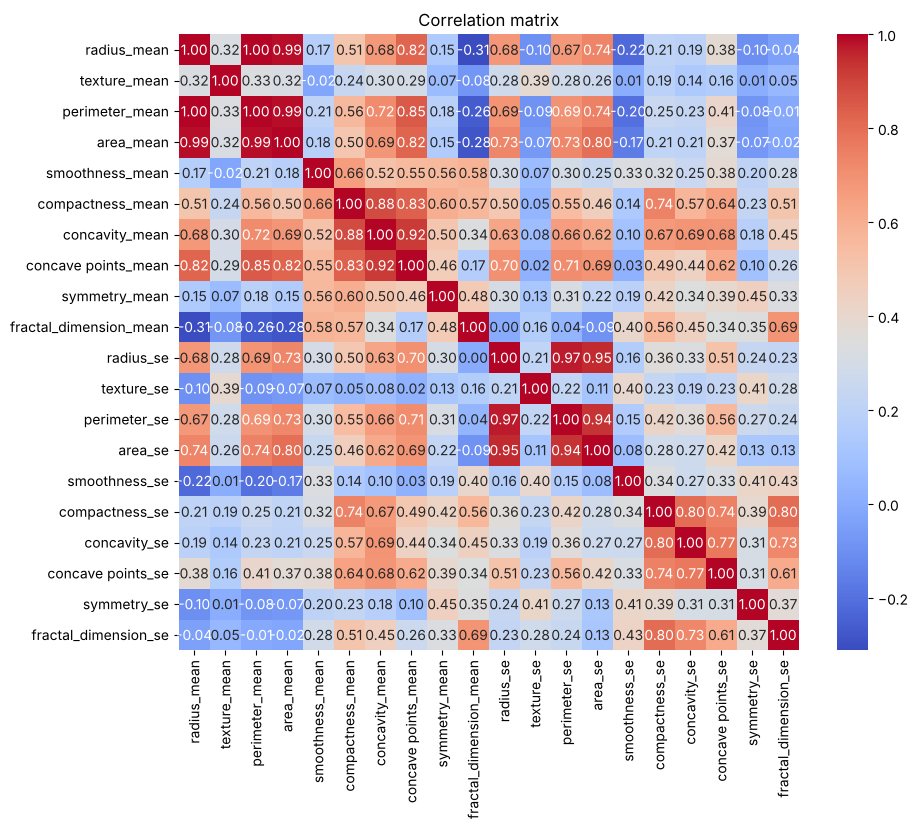

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(cancer_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix')
plt.show()

**Result.** After dropping the `_worst` columns, 7 pairs with |r| > 0.9 remain. Discarding `radius_mean`, `area_mean`, `concavity_mean`, `perimeter_se` and `area_se` leaves **15 predictors**, and no correlation among them exceeds 0.9. The highest is `perimeter_mean` – `concave points_mean` (≈ 0.85), so moderate multicollinearity persists, which shows up in the coefficients in Section 8.

Two caveats about the criterion: (1) the differences among `radius`, `perimeter` and `area` are minimal, so choosing one or another is practically indifferent; (2) the correlation with the target was computed on the **whole** dataset, including the test data (see Notes).

---

## 4. Data split and evaluation function

**Goals**
- Separate the predictors `X` from the target `y` using the original `cancer_df` (the feature removal will be part of the pipeline).
- Encode `diagnosis` as 0 (benign) and 1 (malignant).
- Split into training and test sets (80:20) with `random_state=1`.
- Define `evaluate_model(actual, predicted)`, which prints recall, precision and accuracy.

In [12]:
# Separate predictors and target
x = cancer_df.drop(columns=['diagnosis'])
y = cancer_df['diagnosis'].map({'M': 1, 'B': 0})

# Train/test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

# Model evaluation
def evaluate_model(actual, predicted):
    print(f'Recall: {recall_score(actual, predicted)}')
    print(f'Precision: {precision_score(actual, predicted)}')
    print(f'Accuracy: {accuracy_score(actual, predicted)}')

---

## 5. Model 1: correlated features removed (*Correlation_Clean*)

**Goals**
- Create a `preprocessing` transformer with `ColumnTransformer` that drops the correlated columns, using `remainder='passthrough'`.
- Train a `preprocessing` + logistic regression pipeline and evaluate it on the test set.
- Record the metrics in a results dataframe.

In [13]:
# _worst columns + redundant columns to drop
worst_cols += ['radius_mean', 'area_mean', 'concavity_mean', 'perimeter_se', 'area_se']

# Transformer applied before the model
preprocessing = ColumnTransformer([
    ('drop_columns', 'drop', worst_cols)
    ], remainder='passthrough')

# Logistic regression pipeline
logr_model = make_pipeline(preprocessing, LogisticRegression(max_iter=10000))
logr_model.fit(x_train, y_train)
y_pred = logr_model.predict(x_test)
evaluate_model(y_test, y_pred)

# Results dataframe
results = pd.DataFrame(columns=['Model', 'Recall', 'Precision', 'Accuracy'])
results.loc[0] = ['Correlation_Clean', recall_score(y_test, y_pred), precision_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
display(results)

Recall: 0.7619047619047619
Precision: 0.8888888888888888
Accuracy: 0.8771929824561403


,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193


**Result.** Recall 0.762, precision 0.889, accuracy 0.877. It is the weakest of the three models, but it is **not a fair baseline**: the variables are not scaled (`perimeter_mean` ≈ 92 vs. `smoothness_mean` ≈ 0.1), and `LogisticRegression`'s L2 regularization and optimizer depend on scale. The following models improve largely for that reason (see Section 7).

---

## 6. Model 2: standard scaling + PCA (*Standard_PCA*)

**Goals**
- Build a pipeline with standard scaling, PCA (the minimum number of components that explain ≥ 90 % of the variance) and logistic regression, as an alternative way to reduce multicollinearity.
- Train, evaluate, and add the metrics to the results dataframe.
- Report how many principal components were used.

In [14]:
logr_model_pca = make_pipeline(preprocessing, StandardScaler(), PCA(n_components=0.90), LogisticRegression(max_iter=10000))
logr_model_pca.fit(x_train, y_train)
y_pred = logr_model_pca.predict(x_test)
evaluate_model(y_test, y_pred)

results.loc[1] = ['Standard_PCA', recall_score(y_test, y_pred), precision_score(y_test, y_pred), accuracy_score(y_test, y_pred)]
display(results)

Recall: 0.9047619047619048
Precision: 0.9743589743589743
Accuracy: 0.956140350877193


,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140


In [15]:
# Number of principal components kept (>= 90 % of the variance)
pca_step = logr_model_pca.named_steps['pca']
print(f'Principal components used: {pca_step.n_components_}')
print(f'Cumulative explained variance: {pca_step.explained_variance_ratio_.sum():.1%}')

Principal components used: 7
Cumulative explained variance: 90.5%


**Result.** PCA kept **7 components** (out of 15 variables) and reached recall 0.905, precision 0.974 and accuracy 0.956. The improvement over Model 1 combines the effect of scaling and of reducing multicollinearity; the components are also linear combinations that are hard to interpret clinically.

---

## 7. Model 3: Yeo-Johnson transformation (*Correlation_Yeo*)

**Goals**
- Since almost all variables are skewed (14 of the 15 predictors have skewness > 0.5), build a pipeline with `preprocessing`, a Yeo-Johnson transformation and logistic regression.
- Train, evaluate, and add the metrics to the results dataframe.
- Compare against a control that uses only `StandardScaler`, to isolate the effect of the transformation.

In [16]:
logr_model_yeo = make_pipeline(preprocessing, PowerTransformer(method="yeo-johnson"), LogisticRegression(max_iter=10000))
logr_model_yeo.fit(x_train, y_train)
y_pred_yeo = logr_model_yeo.predict(x_test)
evaluate_model(y_test, y_pred_yeo)

results.loc[2] = ['Correlation_Yeo', recall_score(y_test, y_pred_yeo), precision_score(y_test, y_pred_yeo), accuracy_score(y_test, y_pred_yeo)]
display(results)

Recall: 0.9523809523809523
Precision: 1.0
Accuracy: 0.9824561403508771


,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140
2,Correlation_Yeo,0.952381,1.000000,0.982456


**Result.** Recall 0.952, precision 1.000, accuracy 0.982: the best of the three models.

In [17]:
# Additional analysis: how much of the improvement comes from scaling alone?
logr_model_std = make_pipeline(preprocessing, StandardScaler(), LogisticRegression(max_iter=10000))
logr_model_std.fit(x_train, y_train)
y_pred_std = logr_model_std.predict(x_test)
evaluate_model(y_test, y_pred_std)

Recall: 0.9285714285714286
Precision: 0.975
Accuracy: 0.9649122807017544


**Control: how much does Yeo-Johnson really add?** With only `StandardScaler`, the model reaches recall 0.929, precision 0.975 and accuracy 0.965. Against that control, Yeo-Johnson adds one true positive and removes one false positive, i.e. **a difference of 1–2 patients out of 114**, within the noise of such a small test set. The solid conclusion is that **the jump from 0.76 to ~0.93–0.95 recall comes mainly from scaling**, not from the transformation. Yeo-Johnson (with `standardize=True`) scales and tames the tails, but logistic regression does not require normally distributed variables.

---

## 8. Model coefficients

**Goals**
- Get the names of the predictors used by the Yeo-Johnson model. How many are there?
- Identify the 10 most influential according to coefficient magnitude.
- Plot them in a horizontal bar chart, keeping the sign.

In [18]:
# Names of the predictors used
feature_names = logr_model_yeo.named_steps['columntransformer'].get_feature_names_out()
yeo_names = logr_model_yeo.named_steps['powertransformer'].get_feature_names_out(feature_names)
coefs = logr_model_yeo.named_steps['logisticregression'].coef_[0]
print('Number of predictors:', len(yeo_names))
print(yeo_names)

Number of predictors: 15
['remainder__texture_mean' 'remainder__perimeter_mean'
 'remainder__smoothness_mean' 'remainder__compactness_mean'
 'remainder__concave points_mean' 'remainder__symmetry_mean'
 'remainder__fractal_dimension_mean' 'remainder__radius_se'
 'remainder__texture_se' 'remainder__smoothness_se'
 'remainder__compactness_se' 'remainder__concavity_se'
 'remainder__concave points_se' 'remainder__symmetry_se'
 'remainder__fractal_dimension_se']


In [19]:
coef_df = pd.DataFrame({'Name': yeo_names, 'Coefficient': coefs})
coef_df['Abs_coef'] = coef_df['Coefficient'].abs()
coef_df.sort_values('Abs_coef', ascending=False, inplace=True)
coef_df.head(10)

,Name,Coefficient,Abs_coef
4,remainder__concave points_mean,2.437213,2.437213
0,remainder__texture_mean,1.901142,1.901142
1,remainder__perimeter_mean,1.444827,1.444827
7,remainder__radius_se,1.325590,1.325590
11,remainder__concavity_se,0.999924,0.999924
5,remainder__symmetry_mean,0.783934,0.783934
13,remainder__symmetry_se,-0.723084,0.723084
10,remainder__compactness_se,-0.706822,0.706822
3,remainder__compactness_mean,0.582670,0.582670
12,remainder__concave points_se,-0.564883,0.564883


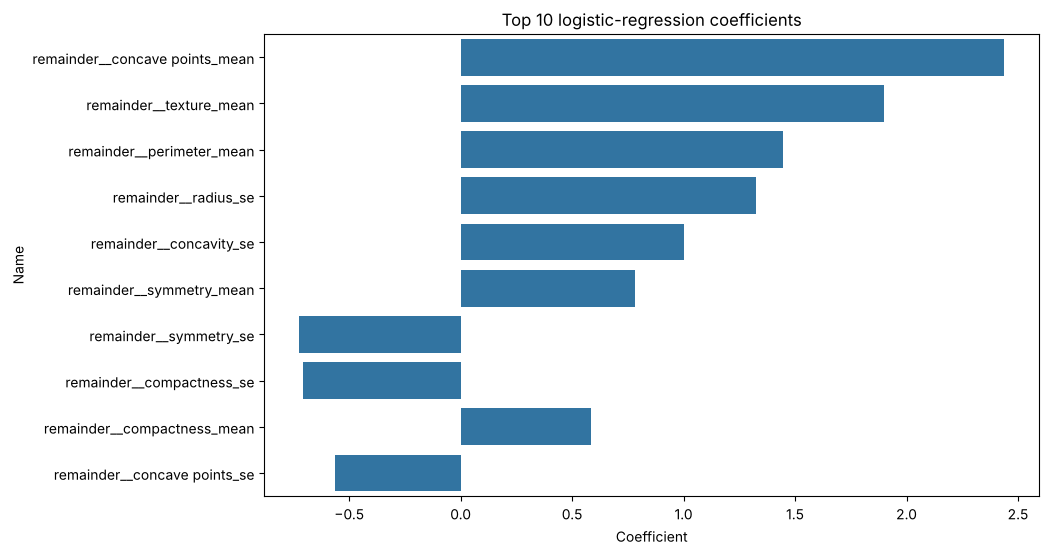

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Name', data=coef_df.head(10))
plt.title('Top 10 logistic-regression coefficients')
plt.show()

**Result.** The model uses **15 predictors**. The coefficients are comparable with each other because `PowerTransformer` standardizes every variable (mean 0, standard deviation 1); each one gives the change in the log-odds of malignancy per standard deviation. The largest are `concave points_mean` (+2.44), `texture_mean` (+1.90), `perimeter_mean` (+1.44), `radius_se` (+1.33) and `concavity_se` (+1.00).

Interpret with care:
- `texture_mean` is the second predictor even though it discriminates less on its own: it carries information that is not in the size variables (Section 2.2).
- The negative coefficients of `symmetry_se`, `compactness_se` and `concave points_se` contrast with the positive sign of their `_mean` counterparts. This is likely an effect of collinearity within the `_se` group (e.g. `compactness_se` – `concavity_se` ≈ 0.80), not a causal relationship.
- The coefficients are shrunk toward zero by L2 regularization (default `C=1`).

---

## 9. Best-model evaluation

**Goals**
- Show the results dataframe.
- Draw the confusion matrix of the best model and interpret each value.
- Draw the ROC curve and describe what it indicates about the ability to separate the classes.

### 9.1 Model comparison and confusion matrix

In [21]:
results

,Model,Recall,Precision,Accuracy
0,Correlation_Clean,0.761905,0.888889,0.877193
1,Standard_PCA,0.904762,0.974359,0.956140
2,Correlation_Yeo,0.952381,1.000000,0.982456


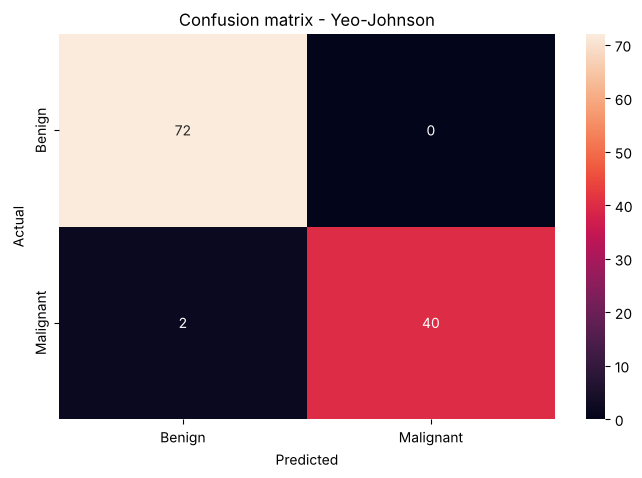

In [22]:
cm = confusion_matrix(y_test, y_pred_yeo)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion matrix - Yeo-Johnson')
plt.show()

**Result.** Confusion matrix of the *Correlation_Yeo* model (test set, 114 patients):

| | Predicted benign | Predicted malignant |
|---|---|---|
| **Actual benign** | TN = 72 | FP = 0 |
| **Actual malignant** | FN = 2 | TP = 40 |

- **TN (72):** benign tumors correctly identified. **TP (40):** malignant tumors correctly identified.
- **FP (0):** no false alarms. **FN (2):** two malignant tumors classified as benign.
- **False negatives** are the most serious error: a real cancer read as benign delays diagnosis and treatment. That is why recall (40/42 = 0.952) is the main metric, although it should not be assessed alone.

### 9.2 ROC curve

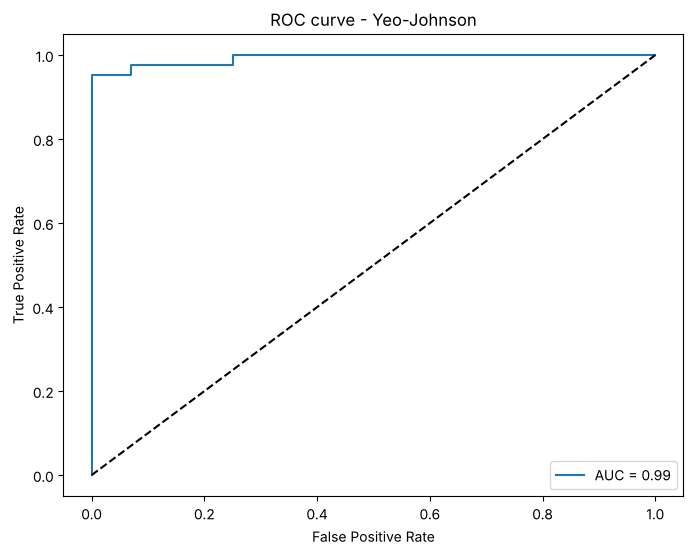

In [23]:
y_prob = logr_model_yeo.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve - Yeo-Johnson')
plt.legend()
plt.show()

**Result.** AUC = 0.99: the curve approaches the top-left corner and lies far above the diagonal (random classifier), i.e. the model almost always ranks malignant tumors above benign ones. It is a very high value, but it is estimated on 114 patients and with a model chosen after looking at the test set (see Notes), so it is probably somewhat optimistic.

---

## 10. Probability distribution and decision threshold

**Goals**
- Plot the distribution of the predicted probability of the positive class (malignant) with overlaid histograms, by actual class.
- What is scikit-learn's default threshold? Which metric matters most in medical diagnosis? How, and why, would you change the threshold?

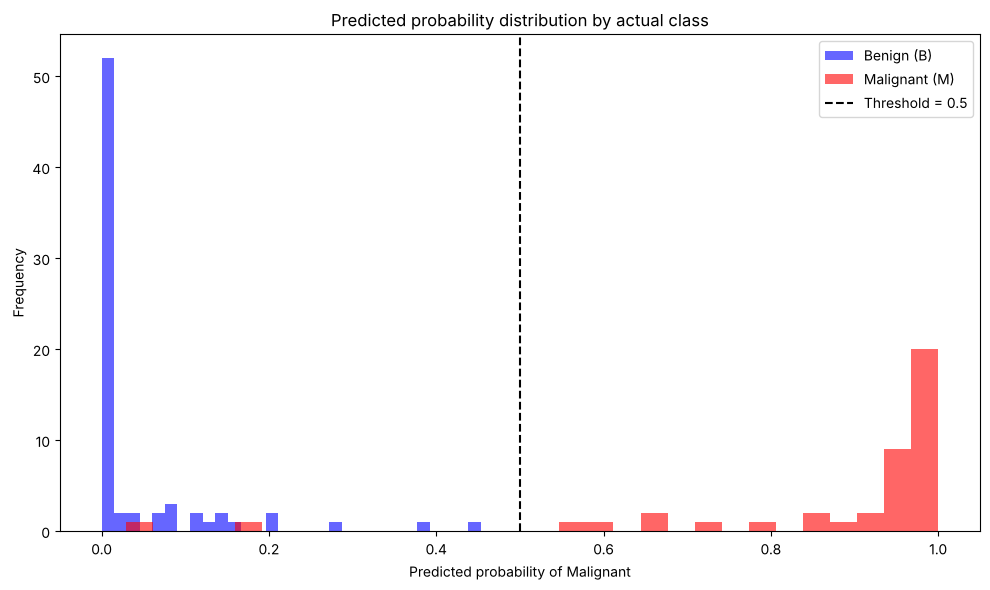

In [24]:
plt.figure(figsize=(10, 6))

# Split probabilities by actual class
proba_benign = y_prob[y_test == 0]
proba_malignant = y_prob[y_test == 1]

plt.hist(proba_benign, bins=30, alpha=0.6, label='Benign (B)', color='blue')
plt.hist(proba_malignant, bins=30, alpha=0.6, label='Malignant (M)', color='red')
plt.axvline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Predicted probability of Malignant')
plt.ylabel('Frequency')
plt.title('Predicted probability distribution by actual class')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Effect of different thresholds on the confusion matrix (test set)
rows = []
for threshold in [0.5, 0.3, 0.2, 0.1]:
    pred_threshold = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_threshold).ravel()
    rows.append({'Threshold': threshold, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                 'Recall': recall_score(y_test, pred_threshold),
                 'Precision': precision_score(y_test, pred_threshold)})
pd.DataFrame(rows)

,Threshold,TP,FP,FN,TN,Recall,Precision
0,0.5,40,0,2,72,0.952381,1.000000
1,0.3,40,2,2,70,0.952381,0.952381
2,0.2,40,5,2,67,0.952381,0.888889
3,0.1,41,11,1,61,0.976190,0.788462


**Result.**
- **Default threshold:** 0.5 (`predict` assigns "malignant" when the probability is ≥ 0.5).
- **Priority metric:** recall, because a false negative (undetected cancer) is far more costly than a false positive (additional tests). Even so, high recall at the expense of very low precision would flood the system with false alarms, so both are monitored.
- **Changing the threshold:** lowering it raises recall at the cost of more false positives. The table above shows, however, that **it does not help in a reasonable way here**: the two false negatives have probabilities of ≈ 0.03 and ≈ 0.17, far below 0.5. With a threshold of 0.3 or 0.2 neither is recovered and 2 and 5 false positives are added; only at 0.1 is one recovered (recall 0.976), at the cost of 11 false positives. The case at p ≈ 0.03 is not recovered by any reasonable threshold: the model is "confident" that it is benign, which suggests an atypical case or a doubtful label worth reviewing.
- The malignant tumors with probability between 0.5 and 0.6 visible in the plot are **correctly classified**; they are simply the closest to the threshold, not errors.
- The threshold should be chosen on validation data with an explicit cost ratio (cost of FN vs. FP), not on the test set.

---

## 11. Notes and next steps

- **Clinical use.** This is an academic exercise on a small, single-source dataset; there is no external validation and the model must not be used for clinical decisions.
- **Data leakage in feature selection.** The correlation with the target (Section 3) was computed on the whole dataset, including the test records. The effect here is small, but the correct approach is to compute it on the training set only, or to integrate the selection into the pipeline. Scaling, PCA and Yeo-Johnson are inside the pipeline, so they do not leak test information.
- **Small test set.** With 42 malignant cases, each false negative moves recall by 2.4 points; a recall of 40/42 has a 95 % (Wilson) confidence interval of roughly 84 %–99 %. Differences of 1–2 patients between models are not significant.
- **Validation.** A single, non-stratified split was used. Repeated stratified cross-validation (`StratifiedKFold`, `stratify=y`) would give a more stable estimate and uncertainty intervals.
- **Selecting the best model on the test set.** Choosing the "best" model and reporting its metrics on the same data yields an optimistic estimate. The correct approach is to select with cross-validation and keep the test set for a final evaluation.
- **Modeling alternatives.** Tune `C` (regularization), try L1/L2 on all 30 variables instead of discarding 15 by hand, and compare against non-linear models (e.g. random forests) before concluding that logistic regression is enough.
- **Threshold and calibration.** Choose the threshold on validation data with explicit costs; check probability calibration if the probabilities will be used as a risk estimate.

---

## AI usage statement

- Anthropic. (2026). *Claude* (claude-sonnet-5-5) [Large language model]. Used to restructure and format the notebook documentation, correct errors in the code and the text, add the complementary analyses (number of PCA components, `StandardScaler` control, threshold table), and translate it into English. https://claude.ai